In [ ]:
# === Setup otomatis untuk Google Colab ===
# Sel ini hanya aktif di Colab. Di tempat lain (Jupyter, Codespaces, laptop)
# sel ini tidak melakukan apa-apa.
import sys, os, subprocess

if "google.colab" in sys.modules:
    REPO = "/content/implementasi-tesis"
    if not os.path.isdir(REPO):
        print("Mengambil data dari GitHub...")
        subprocess.run(["git", "clone", "-q",
                        "https://github.com/avinavini/implementasi-tesis.git", REPO], check=True)
    print("Memasang paket yang dibutuhkan (1-2 menit)...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-r", os.path.join(REPO, "requirements.txt")], check=True)
    import nltk
    for _p in ("stopwords", "punkt", "punkt_tab"):
        nltk.download(_p, quiet=True)
    os.chdir(os.path.join(REPO, "notebooks"))
    print("Selesai. Folder kerja:", os.getcwd())
    print("CATATAN: kalau Colab minta 'Restart runtime', klik Restart lalu")
    print("jalankan sel ini sekali lagi sebelum lanjut ke sel berikutnya.")


# Step 6 — Evaluation Detail

Menjawab RQ1–RQ4 melalui analisis mendalam hasil klasifikasi:
1. Apply model terbaik ke seluruh data
2. Tren sentimen per bulan
3. Word cloud ulasan Negatif
4. Tabel frekuensi 20 kata teratas ulasan Negatif

In [1]:
# Cell 1 — Import & Load
import numpy as np
import pandas as pd
import pickle
import scipy.sparse
import re
import warnings
warnings.filterwarnings('ignore')

import os
# Folder output untuk figur. matplotlib tidak membuat folder induk sendiri,
# jadi savefig() gagal dengan FileNotFoundError pada clone yang masih bersih.
os.makedirs('../output/figures', exist_ok=True)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

from sklearn.metrics import classification_report, confusion_matrix

RANDOM_STATE = 42
label_order  = ['Positif', 'Negatif', 'Netral']

# Load model terbaik (NBC — disimpan sebagai ImbPipeline dari step5)
with open('../models/model_nbc.pkl', 'rb') as f:
    model_best = pickle.load(f)

# Load vectorizer
with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# Load preprocessed data
df = pd.read_csv('../data/ulasan_adakami_2025_preprocessed.csv')
print(f'Data loaded: {len(df):,} ulasan')
print(f'Kolom: {list(df.columns)}')

# Tampilkan info model (handle Pipeline maupun classifier langsung)
try:
    clf_name = type(model_best.named_steps['clf']).__name__
    print(f'Model terbaik: {clf_name} (dalam ImbPipeline)')
except AttributeError:
    print(f'Model terbaik: {type(model_best).__name__}')


Data loaded: 32,905 ulasan
Kolom: ['review_id', 'username', 'rating', 'teks_ulasan', 'tanggal', 'bulan', 'tahun', 'thumbs_up', 'versi_app', 'sentimen', 'teks_bersih']
Model terbaik: MultinomialNB (dalam ImbPipeline)


### Cell 2 — Apply Model ke Seluruh Data (RQ1 & RQ2)

In [2]:
# Cell 2 — Prediksi seluruh data dengan model terbaik
# TF-IDF matrix sudah ada, tapi kita prediksi dari teks_bersih agar konsisten
X_all = vectorizer.transform(df['teks_bersih'].fillna(''))
y_pred_all = model_best.predict(X_all)

df['sentimen_prediksi'] = y_pred_all

# Distribusi hasil prediksi
dist = pd.Series(y_pred_all).value_counts()
print('Distribusi Sentimen (Prediksi Model Terbaik — NBC):')
for label in label_order:
    n   = dist.get(label, 0)
    pct = n / len(df) * 100
    print(f'  {label:<10}: {n:>6,} ({pct:.1f}%)')
print(f'  Total     : {len(df):>6,}')

# Simpan untuk dashboard
df.to_csv('../data/ulasan_dengan_prediksi.csv', index=False)
print('\nTersimpan: ulasan_dengan_prediksi.csv')


Distribusi Sentimen (Prediksi Model Terbaik — NBC):
  Positif   : 19,061 (57.9%)
  Negatif   : 10,030 (30.5%)
  Netral    :  3,814 (11.6%)
  Total     : 32,905

Tersimpan: ulasan_dengan_prediksi.csv


### Cell 3 — Tren Sentimen per Bulan (RQ2) — Gambar 4.11

Proporsi Sentimen per Bulan (%):
sentimen_prediksi  Positif  Negatif  Netral
Jan                   56.0     31.9    12.0
Feb                   56.5     32.2    11.4
Mar                   62.5     25.7    11.8
Apr                   70.0     21.8     8.2
Mei                   61.4     27.4    11.2
Jun                   57.7     30.0    12.4
Jul                   58.3     31.6    10.1
Agu                   51.4     35.2    13.4
Sep                   51.7     34.9    13.4
Okt                   49.2     36.7    14.0
Nov                   53.7     34.2    12.1
Des                   56.2     32.2    11.5



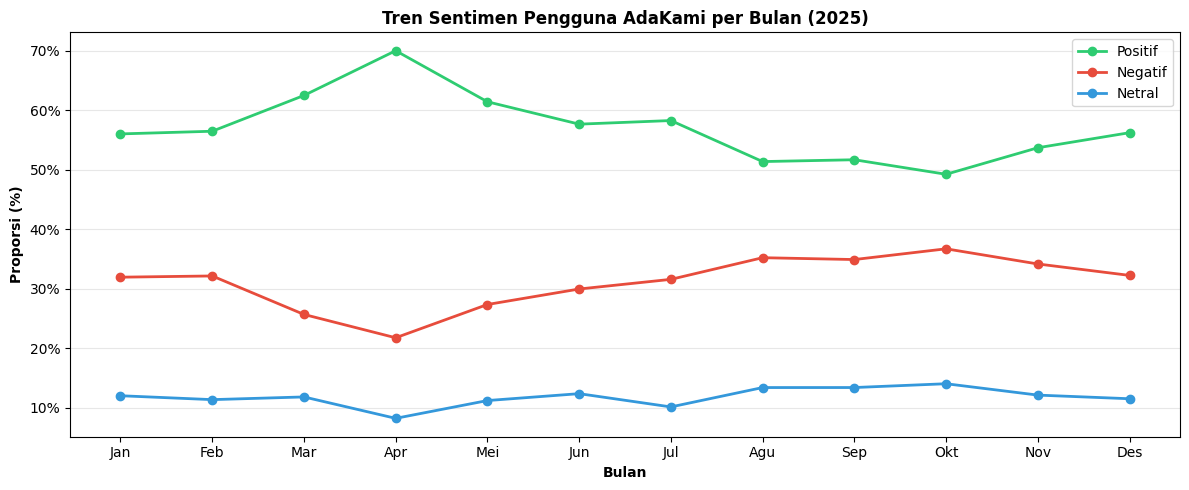

Tersimpan: gambar_4_11_tren_sentimen_bulanan.png (ID) + figures_en/ (EN)


In [3]:
# Cell 3 — Tren sentimen per bulan
bulan_label = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
               7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'}

df['bulan'] = pd.to_numeric(df['bulan'], errors='coerce')
trend = df.groupby(['bulan','sentimen_prediksi']).size().unstack(fill_value=0)

# Hitung proporsi
trend_pct = trend.div(trend.sum(axis=1), axis=0) * 100

# Pastikan semua kolom ada
for lbl in label_order:
    if lbl not in trend_pct.columns:
        trend_pct[lbl] = 0

trend_pct = trend_pct.sort_index()
trend_pct.index = [bulan_label.get(b, str(b)) for b in trend_pct.index]

print('Proporsi Sentimen per Bulan (%):')
print(trend_pct[label_order].round(1).to_string())
print()

fig, ax = plt.subplots(figsize=(12, 5))
colors = {'Positif':'#2ecc71','Negatif':'#e74c3c','Netral':'#3498db'}
for lbl in label_order:
    ax.plot(trend_pct.index, trend_pct[lbl],
            marker='o', linewidth=2, label=lbl, color=colors[lbl])

ax.set_xlabel('Bulan', fontweight='bold')
ax.set_ylabel('Proporsi (%)', fontweight='bold')
ax.set_title('Tren Sentimen Pengguna AdaKami per Bulan (2025)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('../output/figures/gambar_4_11_tren_sentimen_bulanan.png', dpi=150, bbox_inches='tight')

# ── ENGLISH EXPORT (for ICIMTech paper) ─────────────────────────
import os
os.makedirs('../output/figures_en', exist_ok=True)
bulan_label_en = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticklabels(bulan_label_en)
ax.set_xlabel('Month', fontweight='bold')
ax.set_ylabel('Proportion (%)', fontweight='bold')
ax.set_title('Monthly Sentiment Trend of AdaKami User Reviews (2025)',
             fontsize=12, fontweight='bold')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Positive', 'Negative', 'Neutral'])
plt.savefig('../output/figures_en/gambar_4_11_tren_sentimen_bulanan.png', dpi=150, bbox_inches='tight')
# Restore Indonesian labels
bulan_label_id = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
ax.set_xticklabels(bulan_label_id)
ax.set_xlabel('Bulan', fontweight='bold')
ax.set_ylabel('Proporsi (%)', fontweight='bold')
ax.set_title('Tren Sentimen Pengguna AdaKami per Bulan (2025)',
             fontsize=12, fontweight='bold')
ax.legend(handles, ['Positif', 'Negatif', 'Netral'])
# ────────────────────────────────────────────────────────────────

plt.show()
print('Tersimpan: gambar_4_11_tren_sentimen_bulanan.png (ID) + figures_en/ (EN)')

### Cell 4 — Word Cloud Ulasan Negatif (RQ4) — Gambar 4.12

Jumlah ulasan Negatif: 10,030
Total token: 78,241


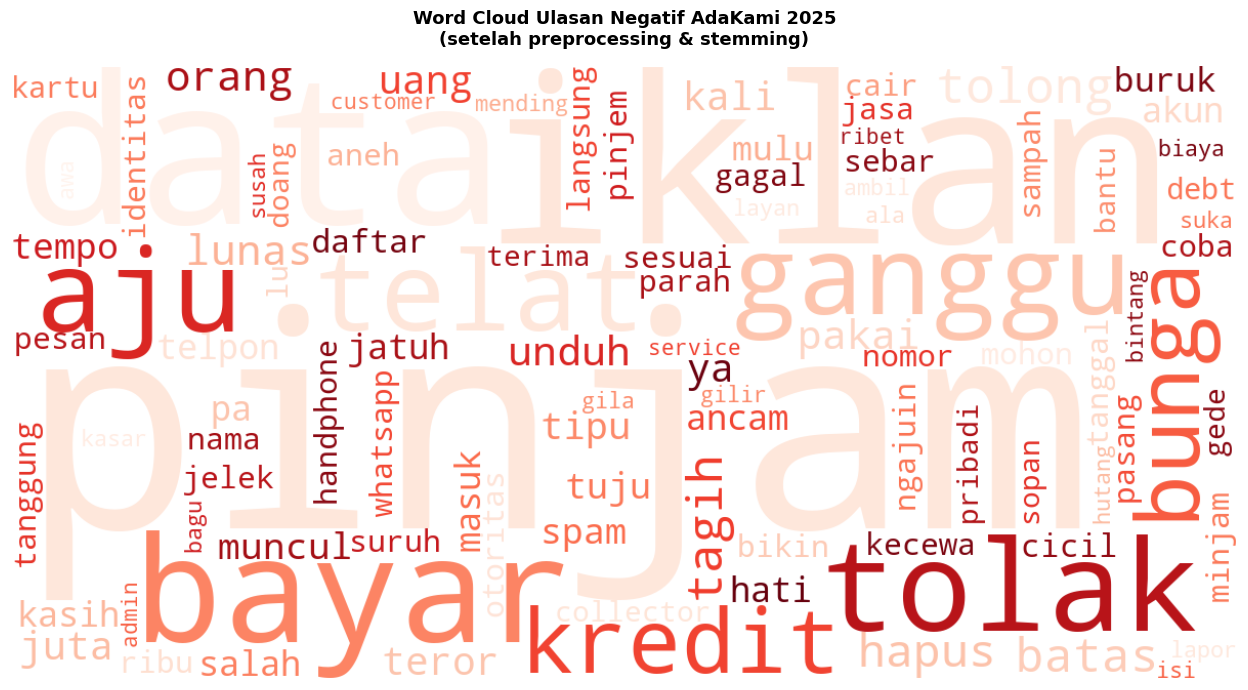

Tersimpan: gambar_4_12_wordcloud_negatif.png (ID) + figures_en/ (EN)


In [4]:
# Cell 4 — Word cloud ulasan Negatif
from wordcloud import WordCloud

df_negatif = df[df['sentimen_prediksi'] == 'Negatif'].copy()
teks_negatif = ' '.join(df_negatif['teks_bersih'].dropna().tolist())

print(f'Jumlah ulasan Negatif: {len(df_negatif):,}')
print(f'Total token: {len(teks_negatif.split()):,}')

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    max_words=100,
    colormap='Reds',
    collocations=False,
    random_state=RANDOM_STATE
).generate(teks_negatif)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud Ulasan Negatif AdaKami 2025\n(setelah preprocessing & stemming)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../output/figures/gambar_4_12_wordcloud_negatif.png', dpi=150, bbox_inches='tight')

# ── ENGLISH EXPORT (for ICIMTech paper) ─────────────────────────
import os
os.makedirs('../output/figures_en', exist_ok=True)
ax.set_title('Word Cloud of Negative Reviews — AdaKami 2025\n(after preprocessing & stemming)',
             fontsize=13, fontweight='bold', pad=15)
plt.savefig('../output/figures_en/gambar_4_12_wordcloud_negatif.png', dpi=150, bbox_inches='tight')
# Restore Indonesian title
ax.set_title('Word Cloud Ulasan Negatif AdaKami 2025\n(setelah preprocessing & stemming)',
             fontsize=13, fontweight='bold', pad=15)
# ────────────────────────────────────────────────────────────────

plt.show()
print('Tersimpan: gambar_4_12_wordcloud_negatif.png (ID) + figures_en/ (EN)')

### Cell 5 — Tabel Frekuensi 20 Kata Teratas Ulasan Negatif (RQ4)

20 Kata Teratas pada Ulasan Negatif AdaKami 2025:
      Kata  Frekuensi  Persentase (%)
1   pinjam       3657            4.67
2    iklan       2055            2.63
3     data       1886            2.41
4    bayar       1775            2.27
5    tolak       1276            1.63
6      aju       1020            1.30
7   ganggu        971            1.24
8    telat        950            1.21
9   kredit        943            1.21
10   bunga        929            1.19
11  tolong        805            1.03
12   tagih        800            1.02
13   batas        746            0.95
14   hapus        724            0.93
15   orang        581            0.74
16   lunas        571            0.73
17   pakai        549            0.70
18   unduh        547            0.70
19    uang        505            0.65
20    juta        495            0.63

Tersimpan: frekuensi_kata_negatif.csv


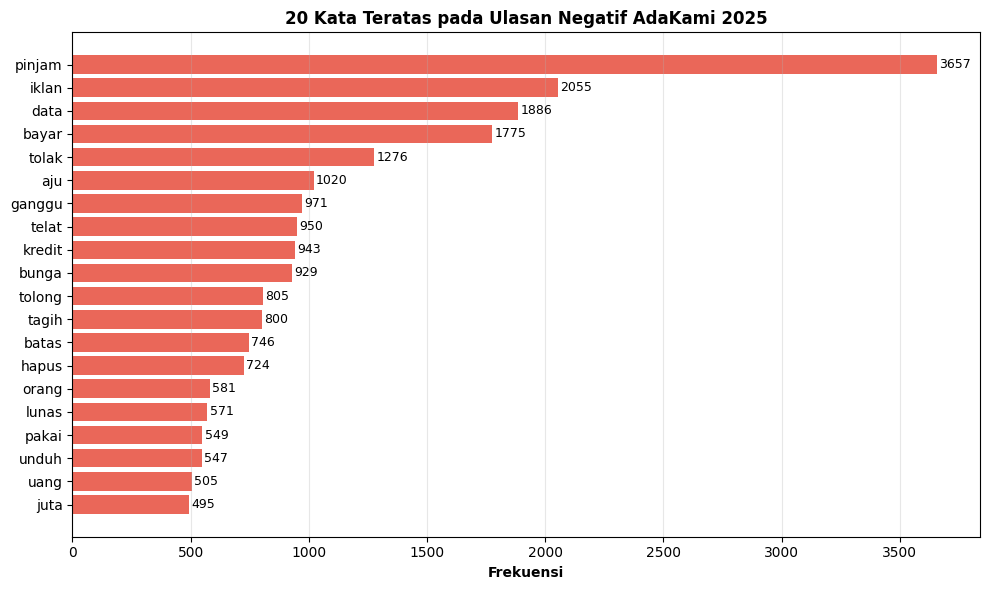

Tersimpan: gambar_4_13_frekuensi_kata_negatif.png


In [5]:
# Cell 5 — Frekuensi kata ulasan Negatif
token_list = teks_negatif.split()
counter    = Counter(token_list)
df_freq    = pd.DataFrame(counter.most_common(20),
                          columns=['Kata', 'Frekuensi'])
df_freq['Persentase (%)'] = (df_freq['Frekuensi'] / len(token_list) * 100).round(2)
df_freq.index = range(1, 21)

print('20 Kata Teratas pada Ulasan Negatif AdaKami 2025:')
print(df_freq.to_string())

# Simpan ke CSV untuk referensi BAB 4
df_freq.to_csv('../data/frekuensi_kata_negatif.csv', index=True)
print('\nTersimpan: frekuensi_kata_negatif.csv')

# Visualisasi bar chart — Gambar 4.13
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_freq['Kata'][::-1], df_freq['Frekuensi'][::-1],
               color='#e74c3c', alpha=0.85)
for bar, val in zip(bars, df_freq['Frekuensi'][::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Frekuensi', fontweight='bold')
ax.set_title('20 Kata Teratas pada Ulasan Negatif AdaKami 2025',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../output/figures/gambar_4_13_frekuensi_kata_negatif.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tersimpan: gambar_4_13_frekuensi_kata_negatif.png')


### Cell 6 — Ringkasan Step 6

In [6]:
# Cell 6 — Ringkasan
print('=' * 60)
print('RINGKASAN STEP 6 — EVALUATION DETAIL')
print('=' * 60)

dist_pred = pd.Series(y_pred_all).value_counts()
print('\nRQ1 — Distribusi Sentimen (seluruh data):')
for lbl in label_order:
    n   = dist_pred.get(lbl, 0)
    pct = n / len(df) * 100
    print(f'  {lbl:<10}: {n:>6,} ({pct:.1f}%)')

print('\nRQ2 — Tren: lihat gambar_4_11_tren_sentimen_bulanan.png')
print('RQ4 — Kata dominan negatif: lihat gambar_4_12 + gambar_4_13')
print(f'\nTop 5 kata negatif:')
for _, row in df_freq.head(5).iterrows():
    print(f"  {row['Kata']:<15} : {row['Frekuensi']:>5} kali")

print('\nOutput tersimpan:')
print('  data/ulasan_dengan_prediksi.csv')
print('  data/frekuensi_kata_negatif.csv')
print('  output/figures/gambar_4_11 s.d. gambar_4_13')
print('\nStep 6 selesai! Lanjut ke Step 7: Dashboard Streamlit')


RINGKASAN STEP 6 — EVALUATION DETAIL

RQ1 — Distribusi Sentimen (seluruh data):
  Positif   : 19,061 (57.9%)
  Negatif   : 10,030 (30.5%)
  Netral    :  3,814 (11.6%)

RQ2 — Tren: lihat gambar_4_11_tren_sentimen_bulanan.png
RQ4 — Kata dominan negatif: lihat gambar_4_12 + gambar_4_13

Top 5 kata negatif:
  pinjam          :  3657 kali
  iklan           :  2055 kali
  data            :  1886 kali
  bayar           :  1775 kali
  tolak           :  1276 kali

Output tersimpan:
  data/ulasan_dengan_prediksi.csv
  data/frekuensi_kata_negatif.csv
  output/figures/gambar_4_11 s.d. gambar_4_13

Step 6 selesai! Lanjut ke Step 7: Dashboard Streamlit
